# K-Means Clustering — Real World Projects

Companion to `kmeans_clustering_notes.md`. Three complete, end-to-end mini-projects using K-Means on realistic scenarios:

1. **Project 1: Customer Segmentation** (Retail/Marketing) — the #1 real-world K-Means use case
2. **Project 2: Image Color Compression** (Computer Vision)
3. **Project 3: Delivery Hub / Store Location Optimization** (Geolocation / Logistics)

Each project follows: **Problem → Data → EDA → Scaling → Elbow Method → K-Means → Business Interpretation.**

---
# Project 1: Customer Segmentation

### Business Problem
A shopping mall wants to run targeted marketing campaigns. Instead of sending the same offer to everyone,
they want to group customers into segments (e.g., "high income, high spenders" vs "low income, low spenders")
so marketing can design a different offer for each segment.

We'll simulate a dataset similar to the famous **"Mall Customers"** dataset (Annual Income vs Spending Score),
which is one of the most common beginner K-Means datasets in the industry.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)

# Simulate 5 realistic customer segments:
# 1) Low income, low spending   2) Low income, high spending (careless spenders)
# 3) High income, low spending (savers)   4) High income, high spending (target customers)
# 5) Medium income, medium spending (average)
seg1 = np.column_stack([np.random.normal(25, 5, 40), np.random.normal(20, 8, 40)])
seg2 = np.column_stack([np.random.normal(25, 5, 40), np.random.normal(80, 8, 40)])
seg3 = np.column_stack([np.random.normal(85, 5, 40), np.random.normal(20, 8, 40)])
seg4 = np.column_stack([np.random.normal(85, 5, 40), np.random.normal(80, 8, 40)])
seg5 = np.column_stack([np.random.normal(55, 5, 40), np.random.normal(50, 8, 40)])

data = np.vstack([seg1, seg2, seg3, seg4, seg5])
customers = pd.DataFrame(data, columns=['Annual_Income_k', 'Spending_Score'])
customers['CustomerID'] = range(1, len(customers) + 1)
customers = customers[['CustomerID', 'Annual_Income_k', 'Spending_Score']]

customers.head()

,CustomerID,Annual_Income_k,Spending_Score
0,1,27.483571,25.907733
1,2,24.308678,21.370946
2,3,28.238443,19.074814
3,4,32.615149,17.591170
4,5,23.829233,8.171824


### Step 1: Exploratory Data Analysis (EDA)

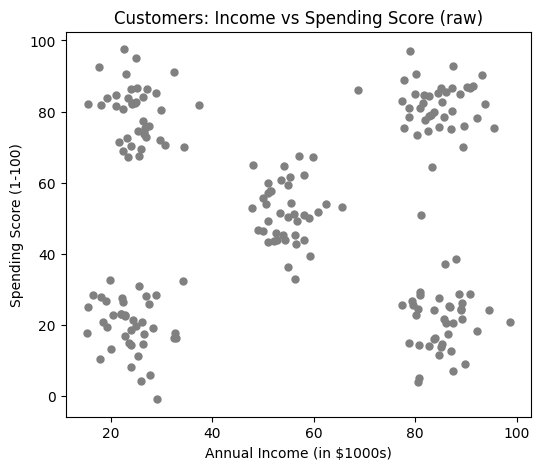

,CustomerID,Annual_Income_k,Spending_Score
count,200.000000,200.000000,200.000000
mean,100.500000,54.667875,50.892177
std,57.879185,27.476700,28.086187
min,1.000000,15.201649,-0.957961
25%,50.750000,25.793320,24.117784
50%,100.500000,54.584816,51.334943
75%,150.250000,82.868191,78.483274
max,200.000000,98.600846,97.523645


In [2]:
plt.figure(figsize=(6, 5))
plt.scatter(customers['Annual_Income_k'], customers['Spending_Score'], s=25, color='gray')
plt.xlabel("Annual Income (in $1000s)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customers: Income vs Spending Score (raw)")
plt.show()

customers.describe()

### Step 2: Scale the Features

As covered in the notes, K-Means uses distance — so features must be on comparable scales before clustering.

In [3]:
features = customers[['Annual_Income_k', 'Spending_Score']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

### Step 3: Elbow Method to Choose K

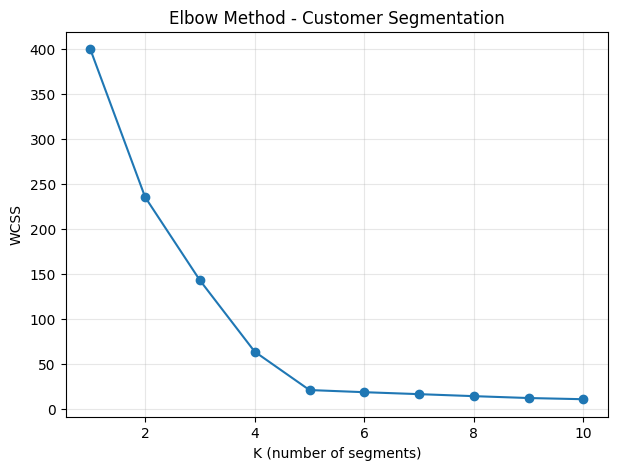

In [4]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(features_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method - Customer Segmentation")
plt.xlabel("K (number of segments)")
plt.ylabel("WCSS")
plt.grid(alpha=0.3)
plt.show()

### Step 4: Fit Final K-Means Model (K=5)

Silhouette Score for K=5: 0.726


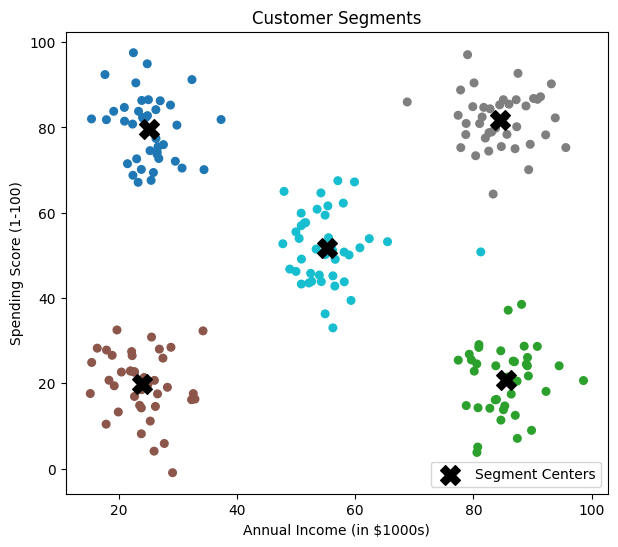

In [5]:
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
customers['Segment'] = kmeans_final.fit_predict(features_scaled)

sil_score = silhouette_score(features_scaled, customers['Segment'])
print(f"Silhouette Score for K={optimal_k}: {sil_score:.3f}")

plt.figure(figsize=(7, 6))
scatter = plt.scatter(customers['Annual_Income_k'], customers['Spending_Score'],
                       c=customers['Segment'], cmap='tab10', s=30)
centers_original_scale = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centers_original_scale[:, 0], centers_original_scale[:, 1],
            c='black', marker='X', s=200, label='Segment Centers')
plt.xlabel("Annual Income (in $1000s)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments")
plt.legend()
plt.show()

### Step 5: Business Interpretation

This is the step most beginner tutorials skip — but it's the whole point of doing this in the real world: **turning clusters into business decisions.**

In [6]:
segment_summary = customers.groupby('Segment')[['Annual_Income_k', 'Spending_Score']].mean().round(1)
segment_summary['Count'] = customers.groupby('Segment').size()
segment_summary = segment_summary.sort_values('Spending_Score', ascending=False)
print(segment_summary)

print()
print("Business Interpretation:")
print("- High income + High spending  -> VIP customers -> send premium/loyalty offers")
print("- Low income + High spending   -> Impulsive spenders -> good for flash sales/discount alerts")
print("- High income + Low spending   -> Savers/untapped potential -> targeted premium ads to convert them")
print("- Low income + Low spending    -> Budget shoppers -> value/bundle offers")
print("- Medium income + Medium spending -> Average customers -> general seasonal campaigns")

         Annual_Income_k  Spending_Score  Count
Segment                                        
3                   84.5            81.8     40
0                   25.1            79.7     40
4                   55.2            51.7     41
1                   85.4            20.8     39
2                   23.9            19.8     40

Business Interpretation:
- High income + High spending  -> VIP customers -> send premium/loyalty offers
- Low income + High spending   -> Impulsive spenders -> good for flash sales/discount alerts
- High income + Low spending   -> Savers/untapped potential -> targeted premium ads to convert them
- Low income + Low spending    -> Budget shoppers -> value/bundle offers
- Medium income + Medium spending -> Average customers -> general seasonal campaigns


---
# Project 2: Image Color Compression using K-Means

### Business/Technical Problem
A raw image can have millions of unique colors (24-bit RGB = ~16.7 million possible colors), which takes
a lot of storage. Many real image compression tools **reduce the number of colors** in an image while
keeping it visually similar. K-Means is a classic technique for this: **treat every pixel's (R, G, B) values
as a data point, cluster similar colors together, and replace every pixel with its cluster's centroid color.**

This is a genuinely used real-world technique (related to "color quantization").

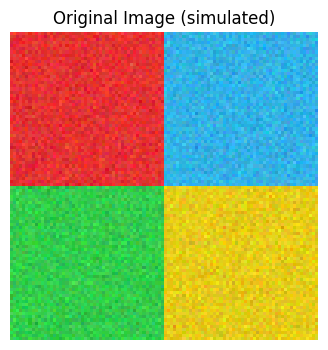

Original image shape: (100, 100, 3)
Unique colors (approx, due to noise): 10000


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Create a synthetic colorful image (since we don't have file upload access in this notebook).
# If you have your own image, replace this block with:
#   from matplotlib.image import imread
#   img = imread('your_image.jpg') / 255.0
np.random.seed(0)
h, w = 100, 100
img = np.zeros((h, w, 3))
img[:50, :50] = [0.9, 0.2, 0.2]       # red block
img[:50, 50:] = [0.2, 0.7, 0.9]       # blue block
img[50:, :50] = [0.2, 0.8, 0.3]       # green block
img[50:, 50:] = [0.9, 0.8, 0.1]       # yellow block
noise = np.random.normal(0, 0.05, img.shape)
img = np.clip(img + noise, 0, 1)  # add slight noise so it's not perfectly flat, like a real photo

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title("Original Image (simulated)")
plt.axis('off')
plt.show()

print("Original image shape:", img.shape)
print("Unique colors (approx, due to noise):", len(np.unique(img.reshape(-1, 3), axis=0)))

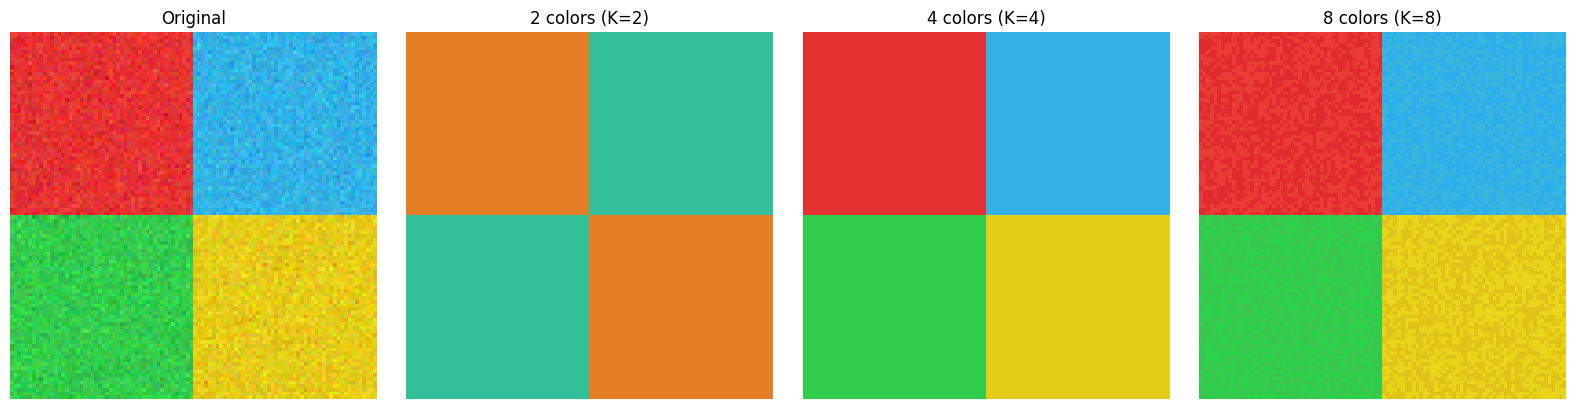

Notice: as K increases, the compressed image looks closer to the original.
This is the exact same trade-off as the Elbow Method - more clusters = more detail, more storage.


In [8]:
def compress_image_kmeans(image, n_colors):
    """Reduce an image to n_colors using K-Means clustering on pixel RGB values."""
    h, w, c = image.shape
    pixels = image.reshape(-1, c)  # every pixel becomes a data point (R, G, B)

    kmeans = KMeans(n_clusters=n_colors, n_init=5, random_state=42)
    labels = kmeans.fit_predict(pixels)
    new_colors = kmeans.cluster_centers_[labels]  # replace each pixel with its cluster's centroid color

    compressed_image = new_colors.reshape(h, w, c)
    return compressed_image, kmeans


fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis('off')

for i, n_colors in enumerate([2, 4, 8], start=1):
    compressed, km = compress_image_kmeans(img, n_colors)
    axes[i].imshow(compressed)
    axes[i].set_title(f"{n_colors} colors (K={n_colors})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("Notice: as K increases, the compressed image looks closer to the original.")
print("This is the exact same trade-off as the Elbow Method - more clusters = more detail, more storage.")

### Why This Matters in Practice
- Reduces file size (fewer unique colors = better compression with formats like PNG/GIF).
- Used in techniques like **color quantization**, generating **color palettes** for design tools, and even simple **image segmentation** (e.g., roughly separating sky vs ground vs objects by color).

---
# Project 3: Delivery Hub / Store Location Optimization (Geolocation Clustering)

### Business Problem
A food delivery / logistics company has thousands of customer delivery locations (latitude, longitude)
across a city. They want to open a small number of **delivery hubs (dark stores)** such that the average
distance from each hub to its nearby customers is minimized — reducing delivery time and cost.

This is a real-world use of K-Means in logistics and urban planning: **the resulting centroids are literally
the recommended hub locations**, and each cluster = customers served by that hub.

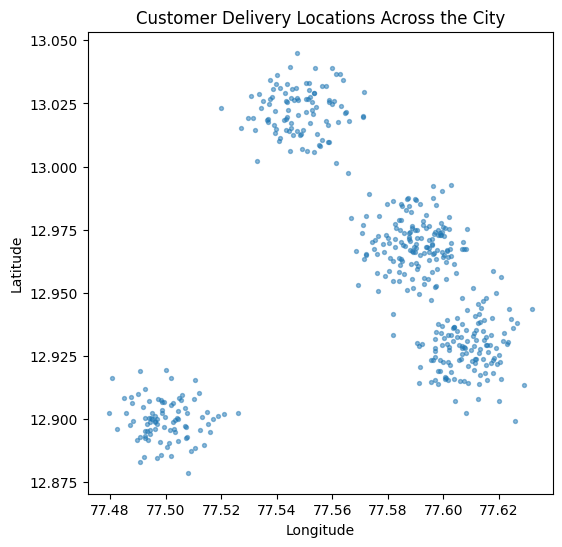

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

np.random.seed(7)

# Simulate customer delivery coordinates around 4 city neighborhoods
neighborhoods = [
    (12.97, 77.59, 150),   # (lat, lon, num_customers) - e.g., Neighborhood A
    (12.93, 77.61, 130),   # Neighborhood B
    (13.02, 77.55, 100),   # Neighborhood C
    (12.90, 77.50, 90),    # Neighborhood D
]

rows = []
for lat, lon, n in neighborhoods:
    lats = np.random.normal(lat, 0.01, n)
    lons = np.random.normal(lon, 0.01, n)
    rows.append(np.column_stack([lats, lons]))

customer_locations = np.vstack(rows)
locations_df = pd.DataFrame(customer_locations, columns=['latitude', 'longitude'])

plt.figure(figsize=(6, 6))
plt.scatter(locations_df['longitude'], locations_df['latitude'], s=8, alpha=0.5)
plt.title("Customer Delivery Locations Across the City")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Elbow Method for Number of Hubs

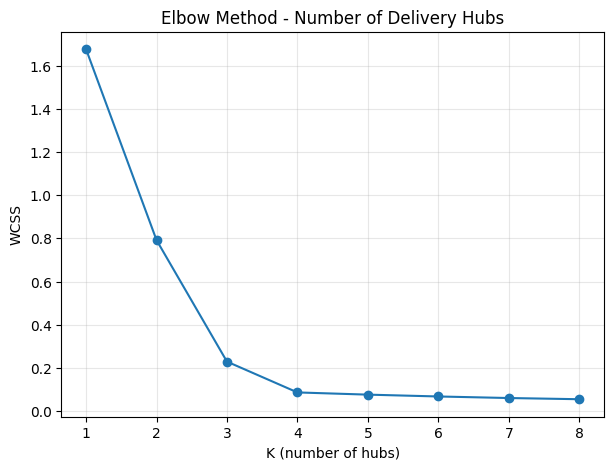

In [10]:
wcss = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(locations_df)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 9), wcss, marker='o')
plt.title("Elbow Method - Number of Delivery Hubs")
plt.xlabel("K (number of hubs)")
plt.ylabel("WCSS")
plt.grid(alpha=0.3)
plt.show()

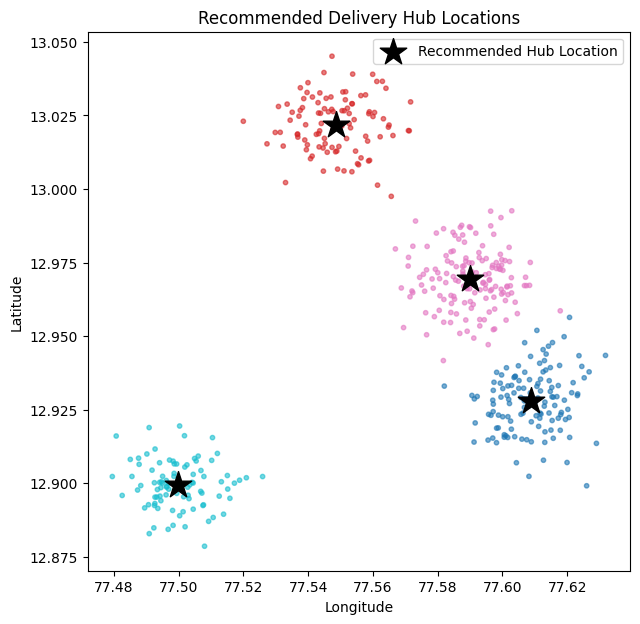

    latitude  longitude  customers_served
0  12.928018  77.608826               129
1  13.021880  77.548528               100
2  12.969358  77.590079               151
3  12.899563  77.499953                90


In [11]:
num_hubs = 4  # chosen from the elbow plot (matches our 4 simulated neighborhoods)
kmeans_hubs = KMeans(n_clusters=num_hubs, n_init=10, random_state=42)
locations_df['assigned_hub'] = kmeans_hubs.fit_predict(locations_df[['latitude', 'longitude']])
hub_locations = kmeans_hubs.cluster_centers_

plt.figure(figsize=(7, 7))
plt.scatter(locations_df['longitude'], locations_df['latitude'],
            c=locations_df['assigned_hub'], cmap='tab10', s=10, alpha=0.6)
plt.scatter(hub_locations[:, 1], hub_locations[:, 0],
            c='black', marker='*', s=400, label='Recommended Hub Location')
plt.title("Recommended Delivery Hub Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

hub_summary = pd.DataFrame(hub_locations, columns=['latitude', 'longitude'])
hub_summary['customers_served'] = locations_df.groupby('assigned_hub').size().values
print(hub_summary)

### Business Interpretation
Each black star is a suggested **hub location** — the average (centroid) position of all customers assigned to it.
Opening delivery hubs at these exact coordinates minimizes the average distance to customers in that zone, which directly translates to **faster deliveries and lower fuel/logistics cost.**

This same technique (in real life) is used for:
- Placing new retail store branches
- Placing ATMs / cell towers
- Ride-sharing driver positioning zones (e.g., Uber/Ola surge zones are related to this kind of spatial clustering)

---
## Final Recap of All 3 Projects

| Project | Data Point = | Cluster Meaning | Centroid Meaning |
|---|---|---|---|
| Customer Segmentation | One customer (income, spending) | A customer segment | "Typical" customer profile of that segment |
| Image Compression | One pixel (R, G, B) | A group of similar colors | The representative color used to replace all pixels in that group |
| Hub Location Optimization | One delivery location (lat, lon) | Customers served by one hub | The optimal hub location for that zone |

This is the real power of K-Means: **the exact same algorithm, with zero changes to its core logic, solves marketing, computer vision, and logistics problems** — only the meaning of "data point," "cluster," and "centroid" changes based on the business context.
